In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning
)

## Datos

In [3]:
df = pd.read_csv("~/Downloads/Cancer.csv")
print(df.head())

   samples   type  1007_s_at   1053_at    117_at    121_at  1255_g_at  \
0       84  basal   9.850040  8.097927  6.424728  7.353027   3.029122   
1       85  basal   9.861357  8.212222  7.062593  7.685578   3.149468   
2       87  basal  10.103478  8.936137  5.735970  7.687822   3.125931   
3       90  basal   9.756875  7.357148  6.479183  6.986624   3.181638   
4       91  basal   9.408330  7.746404  6.693980  7.333426   3.169923   

    1294_at   1316_at   1320_at  ...  AFFX-r2-Ec-bioD-3_at  \
0  6.880079  4.963740  4.408328  ...             12.229711   
1  7.542283  5.129607  4.584418  ...             12.178531   
2  6.562369  4.813449  4.425195  ...             12.125108   
3  7.802344  5.490982  4.567956  ...             12.111235   
4  7.610457  5.372469  4.424426  ...             12.173642   

   AFFX-r2-Ec-bioD-5_at  AFFX-r2-P1-cre-3_at  AFFX-r2-P1-cre-5_at  \
0             11.852955            13.658701            13.477698   
1             11.809408            13.750086      

In [4]:
print(df.shape)
df.info()

(151, 54677)
<class 'pandas.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Columns: 54677 entries, samples to AFFX-TrpnX-M_at
dtypes: float64(54675), int64(1), str(1)
memory usage: 63.0 MB


In [5]:
df["type"].value_counts()

type
basal        41
HER          30
luminal_B    30
luminal_A    29
cell_line    14
normal        7
Name: count, dtype: int64

In [6]:
X = df.drop(
    columns=[
        "samples",
        "type"
    ]
)

y = df["type"]
print(X.shape)
print(y.shape)

(151, 54675)
(151,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## PCA 

In [8]:
pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA())
])

pca_pipeline.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('pca', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full

Varianza

In [20]:
pca = pca_pipeline.named_steps["pca"]
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada) # cumsum suma acumulada

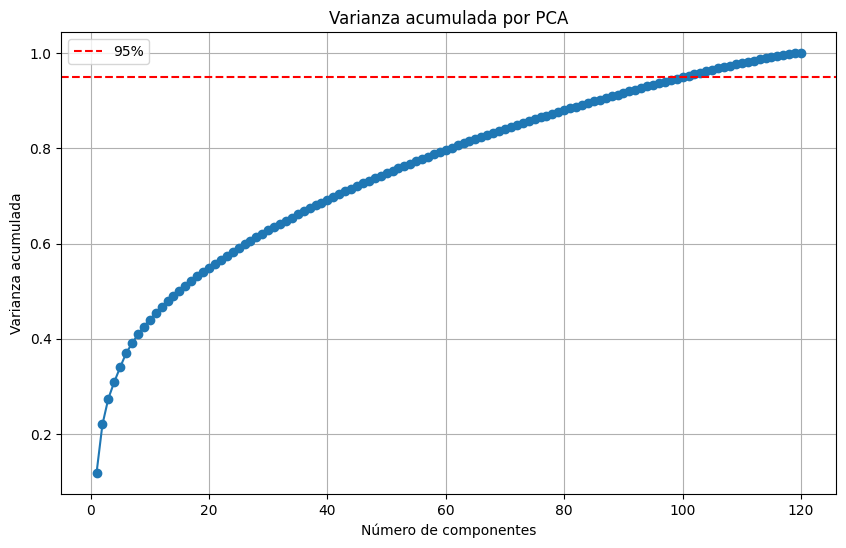

In [22]:
plt.figure(figsize=(10,6))
plt.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, marker="o")
plt.axhline(
    y=0.95,
    color="red",
    linestyle="--",
    label="95%"
)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")

plt.title("Varianza acumulada por PCA")
plt.legend()
plt.grid()
plt.show()

### Número de componentes

In [23]:
n_components = np.argmax(varianza_acumulada >= 0.95) + 1
print(f"Componentes necesarios para explicar el 95% de la varianza: {n_components}")

Componentes necesarios para explicar el 95% de la varianza: 101


# Loadings

 Cuánto contribuye cada variable a un componente principal.

In [26]:
loadings = pd.DataFrame(
  pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))],
    index=X.columns
))
loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC111,PC112,PC113,PC114,PC115,PC116,PC117,PC118,PC119,PC120
1007_s_at,0.003327,0.003235,0.003517,-0.007000,-0.002327,-0.010027,-0.007215,-0.000093,-0.003182,0.002648,...,-0.000894,0.005958,0.000241,0.000228,-0.000324,0.001952,-0.001233,0.004055,0.001072,0.070542
1053_at,-0.004699,-0.009754,-0.000269,-0.004258,-0.002572,-0.001326,0.001709,0.000005,-0.000463,-0.000811,...,0.005221,-0.002466,-0.001887,0.000281,0.000674,0.000665,0.000535,-0.000574,0.001908,-0.069134
117_at,-0.005028,0.004791,-0.002400,0.001470,-0.000849,-0.004557,0.008971,-0.001988,0.008725,-0.000475,...,0.006958,0.003558,-0.002065,-0.000800,0.004150,-0.006047,-0.001562,0.000378,-0.000912,-0.028969
121_at,0.006016,-0.003872,-0.001839,0.007545,-0.006290,0.003068,-0.001074,-0.003487,0.003530,-0.006736,...,0.004345,0.005046,-0.001059,-0.003225,-0.004373,-0.002639,-0.000874,0.002594,0.007719,0.186378
1255_g_at,0.004453,-0.002120,-0.006184,0.003956,-0.006589,-0.003815,0.000436,0.008548,0.003189,-0.002239,...,-0.005452,-0.000859,-0.001462,-0.006543,0.001213,0.006999,-0.001151,0.003824,0.004699,-0.066464


### Variables importantes para PC1 y PC2

In [32]:
pc1 = (
    loadings["PC1"]
    .abs()
    .sort_values(
        ascending=False
    )
)

pc1.head(10)

220904_at       0.010709
1552889_a_at    0.010580
216102_at       0.010548
206849_at       0.010448
208260_at       0.010372
225952_at       0.010273
206119_at       0.010262
239592_at       0.010257
1569393_at      0.010245
242921_at       0.010227
Name: PC1, dtype: float64

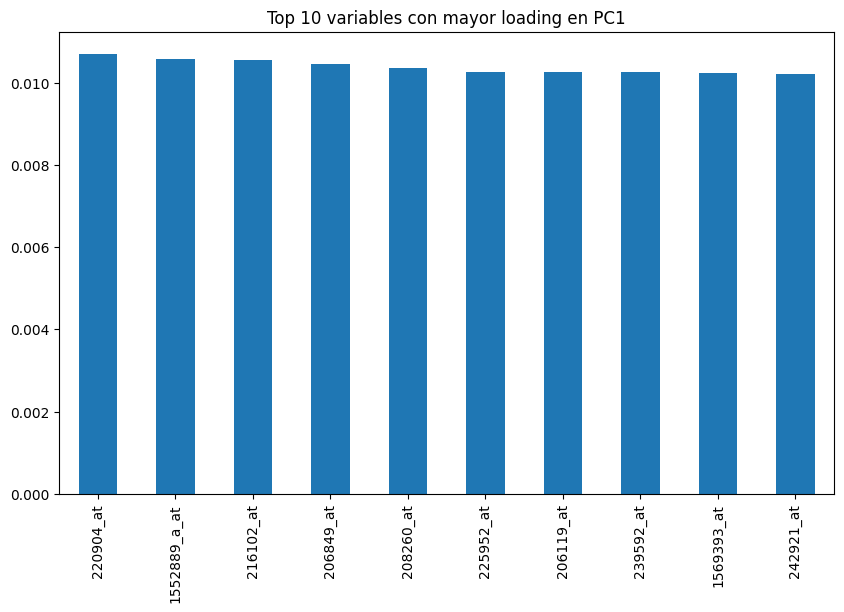

In [34]:
plt.figure(figsize=(10,6))
pc1.head(10).plot(kind="bar")
plt.title( "Top 10 variables con mayor loading en PC1")
plt.show()

In [33]:
pc2 = (
    loadings["PC2"]
    .abs()
    .sort_values(
        ascending=False
    )
)

pc2.head(10)

200795_at      0.012499
222358_x_at    0.012250
201744_s_at    0.012209
211161_s_at    0.012132
202283_at      0.012114
223122_s_at    0.012099
241993_x_at    0.012083
201893_x_at    0.012039
241777_x_at    0.012037
211896_s_at    0.012024
Name: PC2, dtype: float64

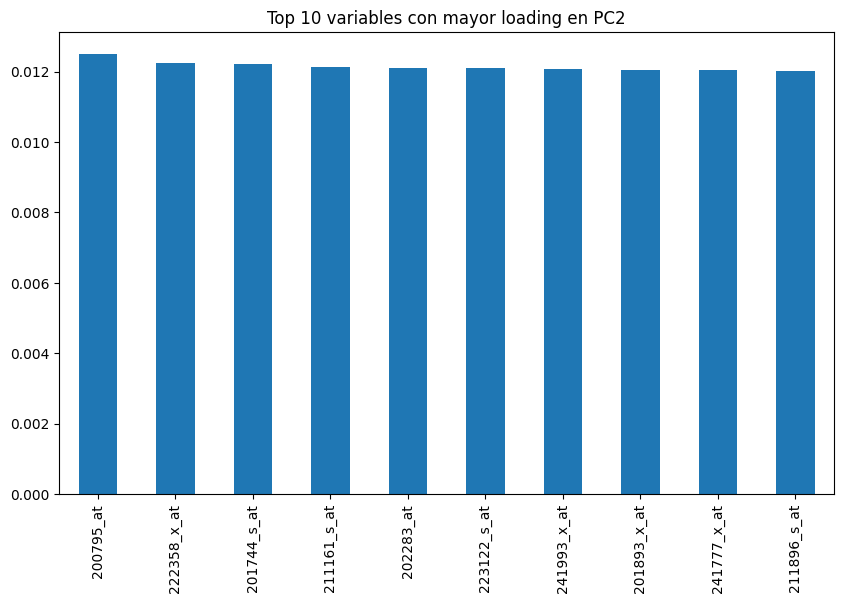

In [35]:
plt.figure(figsize=(10,6))
pc2.head(10).plot(kind="bar")
plt.title( "Top 10 variables con mayor loading en PC2")
plt.show()

### PCA con 2 componentes

In [37]:
pca_2d_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2))
])

X_pca_2d = pca_2d_pipeline.fit_transform(X)

In [38]:
plot_df = pd.DataFrame({
    "PC1": X_pca_2d[:,0],
    "PC2": X_pca_2d[:,1],
    "Clase": y})

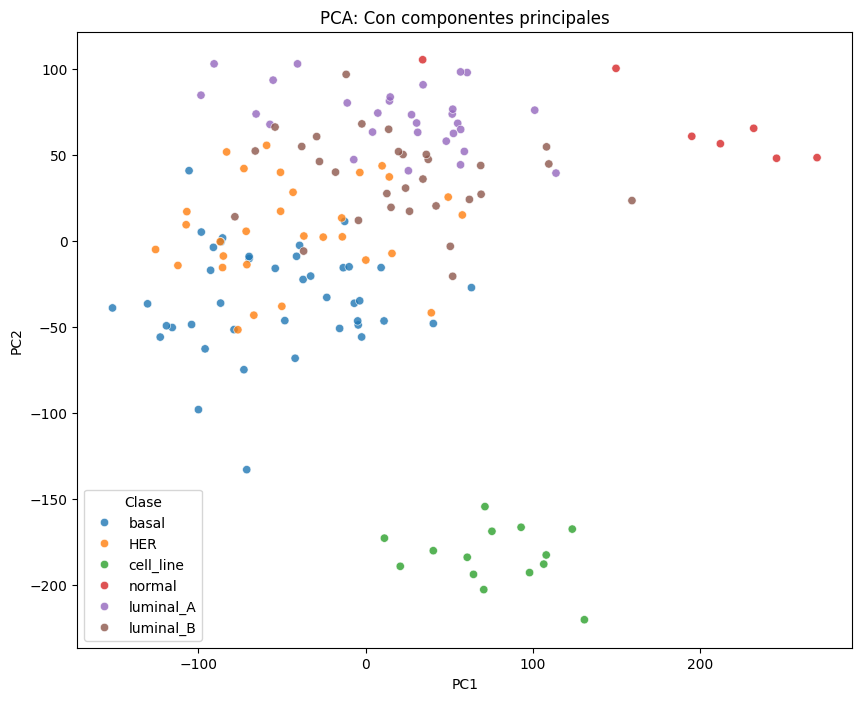

In [41]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Clase",
    alpha=0.8
)
plt.title("PCA: Con componentes principales")
plt.show()

## Logistic Regression

In [90]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("lr", LogisticRegression(
        solver="lbfgs",
        max_iter=10000
    ))
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 

In [91]:
param_grid = {
    "pca__n_components": [5, 10, 20],
    "lr__C": [0.01, 0.1, 1, 10],
    "lr__solver": ["lbfgs"],
    "lr__max_iter": [5000]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    verbose=3,
    n_jobs=-1
)

grid.fit(X_train, y_train) # Esta parte me costo hacer que funcionara


Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV 1/3] END lr__C=0.01, lr__max_iter=5000, lr__solver=lbfgs, pca__n_components=5;, score=0.900 total time=   5.2s
[CV 2/3] END lr__C=0.01, lr__max_iter=5000, lr__solver=lbfgs, pca__n_components=5;, score=0.875 total time=   5.0s
[CV 3/3] END lr__C=0.01, lr__max_iter=5000, lr__solver=lbfgs, pca__n_components=5;, score=0.750 total time=   5.5s
[CV 1/3] END lr__C=0.01, lr__max_iter=5000, lr__solver=lbfgs, pca__n_components=10;, score=0.950 total time=   5.2s
[CV 2/3] END lr__C=0.01, lr__max_iter=5000, lr__solver=lbfgs, pca__n_components=10;, score=0.925 total time=   5.5s
[CV 3/3] END lr__C=0.01, lr__max_iter=5000, lr__solver=lbfgs, pca__n_components=10;, score=0.800 total time=   5.5s
[CV 1/3] END lr__C=0.01, lr__max_iter=5000, lr__solver=lbfgs, pca__n_components=20;, score=0.950 total time=   5.5s
[CV 2/3] END lr__C=0.01, lr__max_iter=5000, lr__solver=lbfgs, pca__n_components=20;, score=0.925 total time=   5.3s
[CV 3/3] END l

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lr__C': [0.01, 0.1, ...], 'lr__max_iter': [5000], 'lr__solver': ['lbfgs'], 'pca__n_components': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candi

#### Mejores parametros y Mejor Accuracy de Validación Cruzada (Cross Validation)

In [75]:
print("Mejores parámetros:")
print(grid.best_params_)

print("\nMejor Accuracy CV:")
print(grid.best_score_)

Mejores parámetros:
{'lr__C': 0.01, 'lr__max_iter': 5000, 'lr__solver': 'lbfgs', 'pca__n_components': 10}

Mejor Accuracy CV:
0.9083333333333333


#### Mejor modelo

In [76]:
best_model = grid.best_estimator_
best_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",10
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'f

#### Predicciones

In [78]:
y_pred = best_model.predict(X_test)
y_pred

array(['basal', 'luminal_B', 'luminal_B', 'luminal_B', 'luminal_A', 'HER',
       'cell_line', 'basal', 'basal', 'luminal_B', 'basal', 'HER',
       'basal', 'HER', 'luminal_A', 'normal', 'HER', 'luminal_A', 'basal',
       'luminal_B', 'HER', 'basal', 'luminal_B', 'HER', 'HER',
       'cell_line', 'luminal_A', 'luminal_B', 'luminal_A', 'luminal_B',
       'cell_line'], dtype=object)

#### Accuracy

In [79]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8710


#### Reporte de clasificación

In [80]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         HER       0.86      1.00      0.92         6
       basal       1.00      0.88      0.93         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       0.80      0.67      0.73         6
   luminal_B       0.75      1.00      0.86         6
      normal       1.00      0.50      0.67         2

    accuracy                           0.87        31
   macro avg       0.90      0.84      0.85        31
weighted avg       0.89      0.87      0.87        31



#### Matriz de Confusión

In [81]:
Matriz_confusion = confusion_matrix(y_test,y_pred)
Matriz_confusion

array([[6, 0, 0, 0, 0, 0],
       [1, 7, 0, 0, 0, 0],
       [0, 0, 3, 0, 0, 0],
       [0, 0, 0, 4, 2, 0],
       [0, 0, 0, 0, 6, 0],
       [0, 0, 0, 1, 0, 1]])

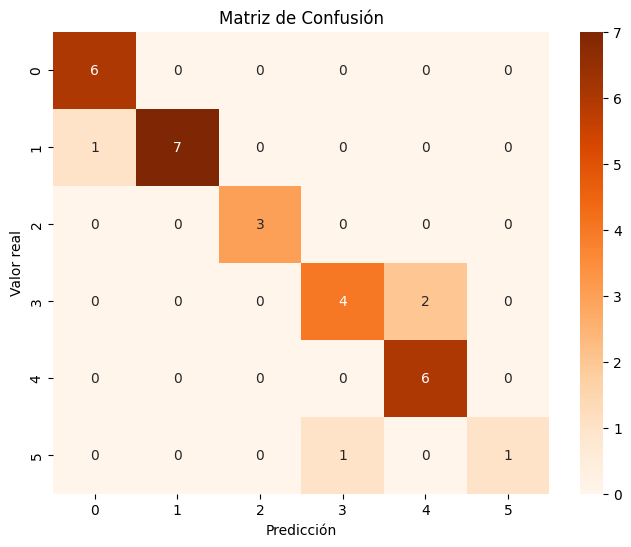

In [83]:
plt.figure(figsize=(8, 6))
sns.heatmap(Matriz_confusion, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.show()

#### Resultados

In [84]:
results = pd.DataFrame(grid.cv_results_)
results[["param_pca__n_components","param_lr__C","mean_test_score","rank_test_score"]].sort_values(by="rank_test_score")

,param_pca__n_components,param_lr__C,mean_test_score,rank_test_score
1,10,0.01,0.908333,1
5,20,0.10,0.908333,1
7,10,1.00,0.900000,3
2,20,0.01,0.900000,3
4,10,0.10,0.891667,5
8,20,1.00,0.891667,6
10,10,10.00,0.875000,7
11,20,10.00,0.866667,8
0,5,0.01,0.841667,9
6,5,1.00,0.841667,9
